In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [2]:
def extract_module_from_path(path):
    """Extract module name from program path"""
    if '/results/x86_64/latest/' in path:
        parts = path.split('/results/x86_64/latest/')[-1].split('/')
        if len(parts) >= 2:
            return parts[0]  # module-name part
    return None

def load_model_checker_data(csv_file='results.csv'):
    """Load model checker results - only from results/x86_64/latest"""
    df = pd.read_csv(csv_file)
    
    ## Filter to completed verifications only
    #df_complete = df[df['completed'] == True].copy()
    df_complete = df
    
    # Filter to only include programs under results/x86_64/latest
    df_filtered = df_complete[df_complete['program_path'].str.contains('/results/x86_64/latest/', na=False)].copy()
    
    # Extract module and file names
    df_filtered['module_name'] = df_filtered['program_path'].apply(extract_module_from_path)
    df_filtered['file_name'] = df_filtered['program_path'].apply(
        lambda x: x.split('/')[-2] if len(x.split('/')) >= 2 else x
    )
    
    ## Remove entries without module names
    #df_filtered = df_filtered.dropna(subset=['module_name'])
    
    return df_filtered

chain_columns = {
    "Module": "str",
    "Empty": "bool",
    "Segment Type": "str",
    "Dependency Type": "str",
    "Optimization Phase": "str",
    "From": "str",
    "To": "str",
    "Matched": "bool",
    "Chain ID": "str",
    "Matchable": "bool"
}

def load_dependency_data(results_dir='results/x86_64/latest'):
    """Load dependency chain data"""
    chains_files = glob.glob(f"{results_dir}/**/Enhanced_Chains.csv", recursive=True)
    
    all_chains = []
    for file_path in chains_files:
        try:
            df = pd.read_csv(file_path)
            if len(df) > 0:
                all_chains.append(df)
        except Exception as e:
            continue
    
    if all_chains:
        return pd.concat(all_chains, ignore_index=True)
    return pd.DataFrame()

# Load data
print("Loading model checker data (filtering to results/x86_64/latest only)...")
df_mc = load_model_checker_data()
print(f"Loaded {len(df_mc)} completed verifications from results/x86_64/latest")

print("Loading dependency data...")
df_deps = load_dependency_data()
print(f"Loaded {len(df_deps)} dependency records")

print(f"\nFiltered dataset overview:")
print(f"  Unique modules: {df_mc['module_name'].nunique()}")
print(f"  Unique files: {df_mc['file_name'].nunique()}")
if len(df_mc) > 0:
    print(f"  Date range: {df_mc['timestamp'].min()} to {df_mc['timestamp'].max()}")

Loading model checker data (filtering to results/x86_64/latest only)...
Loaded 24965 completed verifications from results/x86_64/latest
Loading dependency data...
Loaded 1955903 dependency records

Filtered dataset overview:
  Unique modules: 2712
  Unique files: 12301
  Date range: 23.02.2026 20:54:00 to 25.02.2026 14:04:25


In [3]:
df_deps

,Module,Empty,Segment Type,Dependency Type,Optimization Phase,From,To,Matched,Chain ID,Matchable
0,net-sctp-protocol,True,Combined,Address Dependency,pre-opt,dst.h,net_namespace.h,True,NaN,True
1,net-sctp-protocol,True,Combined,Address Dependency,pre-opt,net_namespace.h,route.h,True,NaN,True
2,net-sctp-protocol,True,Combined,Address Dependency,pre-opt,protocol.c,NaN,True,NaN,True
3,net-sctp-protocol,True,Combined,Address Dependency,pre-opt,inetdevice.h,protocol.c,True,NaN,True
4,net-sctp-protocol,True,Combined,Address Dependency,pre-opt,dst.h,route.h,True,NaN,True
...,...,...,...,...,...,...,...,...,...,...
1955898,drivers-staging-media-atomisp-pci-atomisp_ioctl,False,Combined,Control Dependency,post-opt,list.h,list.h,False,NaN,True
1955899,drivers-staging-media-atomisp-pci-atomisp_ioctl,False,Combined,Control Dependency,post-opt,list.h,list.h,False,NaN,True
1955900,drivers-staging-media-atomisp-pci-atomisp_ioctl,False,Combined,Control Dependency,post-opt,list.h,list.h,False,NaN,True
1955901,drivers-staging-media-atomisp-pci-atomisp_ioctl,False,Combined,Control Dependency,post-opt,list.h,list.h,False,NaN,True


In [4]:
#print(df_mc.head())

tmp = df_deps.copy()
tmp = tmp[tmp["Optimization Phase"] == "pre-opt"]
tmp = tmp[tmp["Matched"].isin([True, False])]
tmp_matched = tmp[tmp["Matched"] == True]

stat_mods = tmp_matched["Module"].unique()
df_mc_stat = df_mc[df_mc["module_name"].isin(stat_mods)]

fake_mc_stat = df_mc[~df_mc["module_name"].isin(stat_mods)]

print(f"So far {len(stat_mods)} unique modules from static analysis")

print(f"{len(df_mc_stat["module_name"].unique())} unique modules from dynamic analysis, {len(fake_mc_stat["module_name"].unique())} from other sources")

df_mc_stat = df_mc_stat.dropna(subset="verification_result")
df_mc_stat["Analysis"] = "dynamic"

So far 3432 unique modules from static analysis
2435 unique modules from dynamic analysis, 277 from other sources


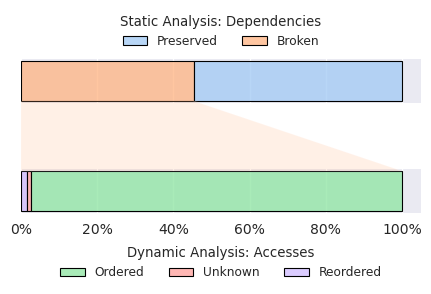

In [5]:
from matplotlib.patches import ConnectionPatch


# Create two-row horizontal stacked bar chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 2), gridspec_kw={"hspace":1.5, "left":0.1}, sharex=True)

df_matching = tmp.copy()

sns.set(style="whitegrid")
sns.set_context("paper")

# First row: Pre-opt chain matching status
df_preopt = df_matching[df_matching['Optimization Phase'] == 'pre-opt']
df_preopt["Dependencies"] = [ ("Preserved" if m else "Broken") for m in df_preopt["Matched"].values ]

# Plot first row
past = sns.color_palette("pastel")
mut = sns.color_palette("muted")

ax1 = sns.histplot(data=df_preopt, y="Optimization Phase", hue="Dependencies", multiple="stack", stat="percent", ax=ax1,
                  palette=past, edgecolor="black", hue_order=["Preserved", "Broken"])

#ax1.set_ylabel("Static\nAnalysis", rotation="horizontal", va="center", ha="right")
ax1.set_ylabel("")
ax1.set_title(' ')

# Second row: Verification results (focusing on unmatched portion)
tx = {"PASS": "Ordered", "UNKNOWN": "Unknown", "FAIL":"Reordered"}
df_mc_stat["Accesses"] = [ tx[m] for m in df_mc_stat["verification_result"].values ]
ax2 = sns.histplot(data=df_mc_stat, y="Analysis", hue="Accesses", multiple="stack", stat="percent", ax=ax2,
                  palette=past[2:], edgecolor="black")

#ax2.set_ylabel("Dynamic\nAnalysis", rotation="horizontal", va="center", ha="right")
ax2.set_ylabel("")
ax2.set_title('')



ax2.set_xlabel("")
ax2.set_xticks(ticks=[0,20,40,60,80,100], labels=[ (f"{x}%") for x in [0,20,40,60,80,100] ])

sns.move_legend(ax1, "lower center", bbox_to_anchor=(0.5, 1), ncols=2, title="Static Analysis: Dependencies")
sns.move_legend(ax2, "upper center", bbox_to_anchor=(0.5, -.5), ncols=3, title="Dynamic Analysis: Accesses")

# Customize both axes
for ax in [ax1, ax2]:
#    ax.set_xlabel('Percentage (%)', fontsize=12)
    ax.set_yticks([])  # Remove y-axis ticks
#    ax.grid(axis='x', alpha=0.3)
    #ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

broken_xy_l = (ax1.patches[0].get_x(), ax1.patches[0].get_y()+ax1.patches[0].get_height())
dyn_xy_l = (ax2.patches[0].get_x(), ax2.patches[0].get_y())

line_l = ConnectionPatch(xyA=broken_xy_l, coordsA=ax1.transData,
                         xyB=dyn_xy_l, coordsB=ax2.transData,)
line_l.set_color([0,0,0,0])
fig.add_artist(line_l)


broken_xy_r = (ax1.patches[1].get_x(), ax1.patches[1].get_y()+ax1.patches[1].get_height())
dyn_xy_r = (ax2.patches[-1].get_x()+ax2.patches[-1].get_width(), ax2.patches[-1].get_y())

line_r = ConnectionPatch(xyA=broken_xy_r, coordsA=ax1.transData,
                         xyB=dyn_xy_r, coordsB=ax2.transData,)
line_r.set_color([0,0,0,0])
fig.add_artist(line_r)

coords = np.concatenate((line_l.get_path().vertices, line_r.get_path().vertices[::-1]))
#print(coords)

col = ax1.patches[0].get_facecolor()

zoom = plt.Polygon(coords,ec=None,fc=col, alpha=0.2, zorder=100, clip_on=False, closed=False)
fig.add_artist(zoom)
sns.despine(left=True, bottom=True)

fig.tight_layout()
plt.savefig("percentage.pdf", bbox_inches="tight")

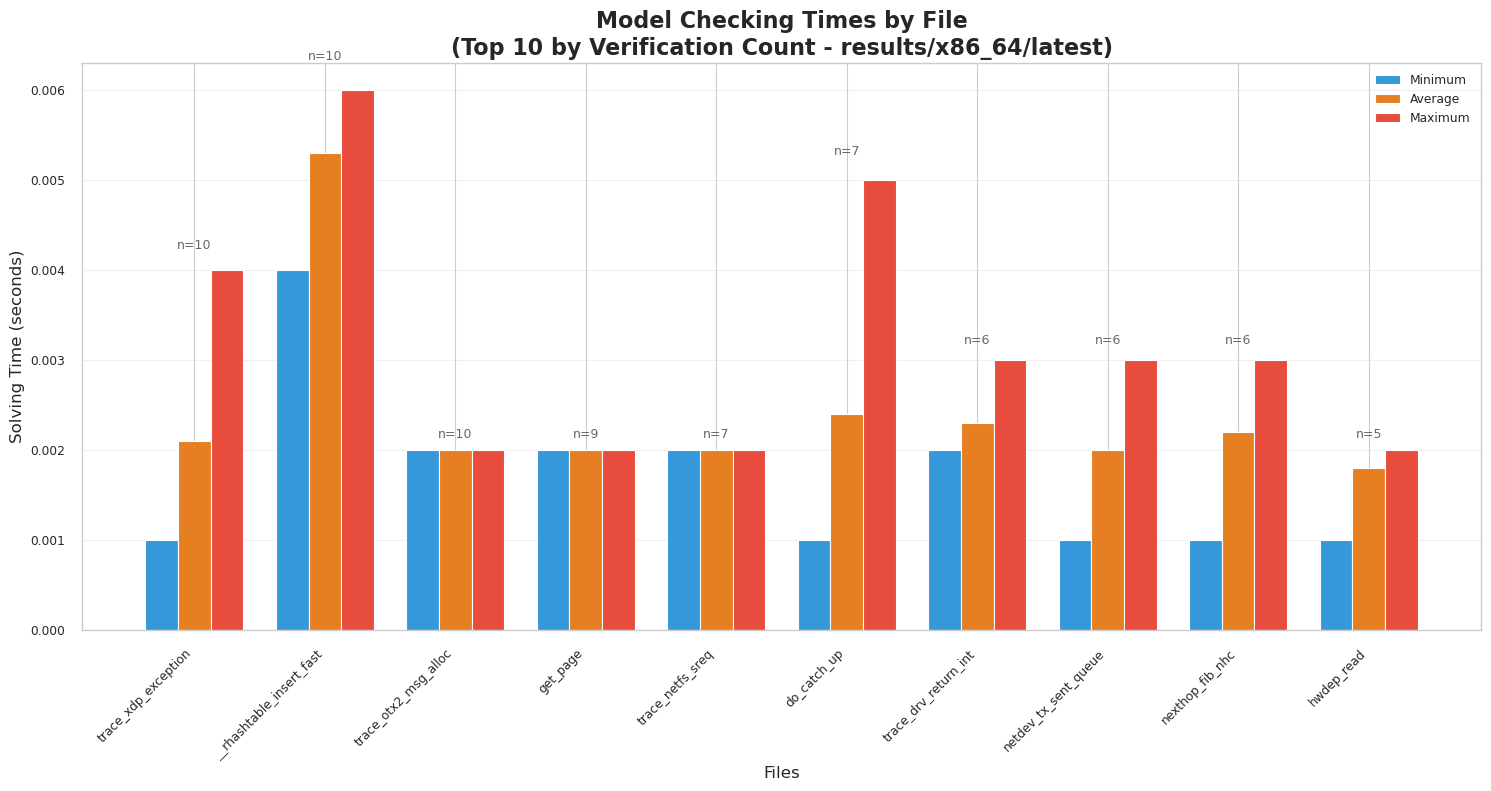

Top 10 Files by Verification Count (results/x86_64/latest):
                          count  min_time  avg_time  max_time  success_rate
file_name                                                                  
trace_xdp_exception          10     0.001    0.0021     0.004      100.0000
__rhashtable_insert_fast     10     0.004    0.0053     0.006      100.0000
trace_otx2_msg_alloc         10     0.002    0.0020     0.002      100.0000
get_page                      9     0.002    0.0020     0.002      100.0000
trace_netfs_sreq              7     0.002    0.0020     0.002      100.0000
do_catch_up                   7     0.001    0.0024     0.005      100.0000
trace_drv_return_int          6     0.002    0.0023     0.003      100.0000
netdev_tx_sent_queue          6     0.001    0.0020     0.003      100.0000
nexthop_fib_nhc               6     0.001    0.0022     0.003      100.0000
hwdep_read                    5     0.001    0.0018     0.002       83.3333


In [6]:
# Get top 10 files by verification count
file_stats = df_mc.groupby('file_name').agg({
    'total_native_solving_time': ['count', 'min', 'max', 'mean'],
    'verification_result': lambda x: (x == 'PASS').sum() / len(x) * 100
}).round(4)

file_stats.columns = ['count', 'min_time', 'max_time', 'avg_time', 'success_rate']
file_stats = file_stats.sort_values('count', ascending=False).head(10)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(15, 8))

x = np.arange(len(file_stats))
width = 0.25

bars1 = ax.bar(x - width, file_stats['min_time'], width, label='Minimum', color='#3498db')
bars2 = ax.bar(x, file_stats['avg_time'], width, label='Average', color='#e67e22')
bars3 = ax.bar(x + width, file_stats['max_time'], width, label='Maximum', color='#e74c3c')

# Customize the plot
ax.set_title('Model Checking Times by File\n(Top 10 by Verification Count - results/x86_64/latest)', 
             fontsize=16, fontweight='bold')
ax.set_ylabel('Solving Time (seconds)', fontsize=12)
ax.set_xlabel('Files', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(file_stats.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add verification count on top
for i, (idx, row) in enumerate(file_stats.iterrows()):
    max_height = max(row['max_time'], row['avg_time'], row['min_time'])
    ax.text(i, max_height + max_height*0.05, 
           f"n={int(row['count'])}", ha='center', va='bottom', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

print("Top 10 Files by Verification Count (results/x86_64/latest):")
print(file_stats[['count', 'min_time', 'avg_time', 'max_time', 'success_rate']].to_string())

In [8]:
all_da = len(df_mc_stat)
ordered = len(df_mc_stat[df_mc_stat["Accesses"] == "Ordered"])
unord = len(df_mc_stat[df_mc_stat["Accesses"] == "Reordered"])
unknwn = len(df_mc_stat[df_mc_stat["Accesses"] == "Unknown"])

print(f"All: {all_da}")
print(f"Ord: {ordered} | {ordered/all_da}%")
print(f"Reord: {unord} | {unord/all_da}%")
print(f"Unknwn: {unknwn} | {unknwn/all_da}%")

All: 20403
Ord: 19873 | 0.9740234279272656%
Reord: 336 | 0.016468166446110866%
Unknwn: 194 | 0.009508405626623535%


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    
dep_types = ['CTRL', 'DATA', 'ADDR']
limits = [20000, 6000, 100000]

class fake_bars:
    patches = []
    errorbar = None
    datavalues = []
    orientation = []
    
    
    def __init__(self, bars):
        self.patches = bars
        self.datavalues = [1 for b in bars]

for i, dep_type in enumerate(df_deps['Dependency Type'].unique()):
    df_dep = df_deps[df_deps['Dependency Type'] == dep_type]
        
    from_counts = df_dep.groupby('From').size().nlargest(10)
    from_counts = from_counts.to_frame(name="Count").reset_index(names="From")
    axes[i] = sns.barplot(data=from_counts, y="From", x="Count", ax=axes[i], color=past[i], edgecolor="black")
    #axes[i].set(yscale="log")
    for label in axes[i].get_xticklabels():
        label.set_rotation(45)
        label.set_fontsize(10)
    axes[i].set_title(dep_types[i])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    labels = [ t.get_text() for t in axes[i].get_yticklabels() ]

    o_labels = []
    i_labels = []
    outs = []
    ins = []
    for j, c in enumerate(axes[i].containers[0]):
        if c.get_width() < limits[i]:
            outs.append(c)
            o_labels.append(labels[j])
        else:
            ins.append(c)
            i_labels.append(labels[j])
    
    axes[i].bar_label(fake_bars(ins) , label_type="center", labels=i_labels)
    axes[i].bar_label(fake_bars(outs), labels=o_labels, padding=5)
    axes[i].set_yticks([])  

sns.despine()
axes[1].set_xlabel("Count", fontsize=12)
plt.tight_layout()
plt.savefig("dep-sources.pdf", bbox_inches="tight")

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    
dep_types = ['CTRL', 'DATA', 'ADDR']
limits = [40000, 15000, 100000]

class fake_bars:
    patches = []
    errorbar = None
    datavalues = []
    orientation = []
    
    
    def __init__(self, bars):
        self.patches = bars
        self.datavalues = [1 for b in bars]

for i, dep_type in enumerate(df_deps['Dependency Type'].unique()):
    df_dep = df_deps[df_deps['Dependency Type'] == dep_type]
        
    from_counts = df_dep.groupby('To').size().nlargest(10)
    from_counts = from_counts.to_frame(name="Count").reset_index(names="To")
    axes[i] = sns.barplot(data=from_counts, y="To", x="Count", ax=axes[i], color=past[i], edgecolor="black")
    #axes[i].set(yscale="log")
    for label in axes[i].get_xticklabels():
        label.set_rotation(45)
        label.set_fontsize(10)
    axes[i].set_title(dep_types[i])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    labels = [ t.get_text() for t in axes[i].get_yticklabels() ]

    o_labels = []
    i_labels = []
    outs = []
    ins = []
    for j, c in enumerate(axes[i].containers[0]):
        if c.get_width() < limits[i]:
            outs.append(c)
            o_labels.append(labels[j])
        else:
            ins.append(c)
            i_labels.append(labels[j])
    
    axes[i].bar_label(fake_bars(ins) , label_type="center", labels=i_labels)
    axes[i].bar_label(fake_bars(outs), labels=o_labels, padding=5)
    axes[i].set_yticks([])  

sns.despine()
axes[1].set_xlabel("Count", fontsize=12)
plt.tight_layout()
plt.savefig("dep-sinks.pdf", bbox_inches="tight")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(5, 3), sharey=True)

sns.set(style="whitegrid")
sns.set_context("paper")

xlabs = ["Before Optimizaitons", "After Optimizations"]

for i, opt in enumerate(["pre-opt", "post-opt"]):
    axes[i] = sns.histplot(
        data=df_deps[df_deps["Optimization Phase"] == opt],
        stat="count", ax=axes[i], edgecolor="black",
        x="Dependency Type", hue="Dependency Type", palette="pastel", multiple="stack")

    axes[i].set_xticks([])
    axes[i].set_xlabel(xlabs[i])

sns.move_legend(axes[0], "upper center", bbox_to_anchor=(0.5, 1.1), title="")
axes[1].get_legend().remove()
sns.despine()
plt.savefig("dep-hist.pdf", bbox_inches="tight")